In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

# Use imblearn's pipeline instead of sklearn's to handle SMOTE correctly inside CV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.base import clone

from scipy.stats import entropy
from tqdm import tqdm
from IPython.display import display

from deep_gp.preprocessing_data_2 import load_data, undersample_class0


In [2]:

data = load_data()
print("\n Original dataset — samples per ISUP class:")
print(data["case_ISUP"].value_counts().sort_index())

# Step 1: undersample class 0 
df_new = undersample_class0(data)
print("\n After undersampling class 0 — samples per ISUP class:")
print(df_new["case_ISUP"].value_counts().sort_index())

# Step 2: create binary target AFTER undersampling
df_new["binary_target"] = (df_new["case_ISUP"] >= 3).astype(int)
print("\n Binary target (0 = ISUP 0–2, 1 = ISUP 3–5):")
print(df_new["binary_target"].value_counts().sort_index())

X = df_new.drop(columns=["case_ISUP", "binary_target"])
y = df_new["binary_target"]




 Original dataset — samples per ISUP class:
case_ISUP
0    589
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64

 After undersampling class 0 — samples per ISUP class:
case_ISUP
0    467
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64

 Binary target (0 = ISUP 0–2, 1 = ISUP 3–5):
binary_target
0    778
1    131
Name: count, dtype: int64


In [ ]:

# NESTED CV WITH SMOTE INSIDE TRAINING FOLD
def evaluate_models_cv_with_tuning(X, y, label):

    print(f"\n=== Feature set: {label} ===")

    
    base_models = {
        "Logistic Regression": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(k_neighbors=3, random_state=42)),
            ("clf", LogisticRegression(
                solver="saga",
                max_iter=30000,
                tol=1e-4
            ))
        ]),

        "KNN": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(k_neighbors=3, random_state=42)),
            ("clf", KNeighborsClassifier())
        ]),

        "Random Forest": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(k_neighbors=3, random_state=42)),
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "XGBoost": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(k_neighbors=3, random_state=42)),
            ("clf", XGBClassifier(
                tree_method="hist",
                eval_metric="logloss",
                random_state=42
            ))
        ]),

        "Gaussian Process": ImbPipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(k_neighbors=3, random_state=42)),
            ("clf", GaussianProcessClassifier(
                kernel=C(1.0, (1e-6, 1e6)) *
                       RBF(length_scale=1.0, length_scale_bounds=(1e-6, 1e6)) +
                       WhiteKernel(noise_level=1e-3),
                n_restarts_optimizer=2,
                random_state=42
            ))
        ])
    }

    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.01, 0.1, 1.0]
        },
        "KNN": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        },
        "Random Forest": {
            "clf__n_estimators": [100, 200, 300, 400, 500],
            "clf__max_depth": [None, 5, 10, 20],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", "log2", None]
        },
        "XGBoost": {
            "clf__n_estimators": [100, 200, 300, 400],
            "clf__learning_rate": [0.01, 0.05, 0.1, 0.3],
            "clf__max_depth": [3, 4, 5, 6],
            "clf__subsample": [0.7, 0.8, 0.9, 1.0],
            "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        "Gaussian Process": {
            "clf__kernel": [
                C(c, (1e-6, 1e6)) * RBF(length_scale=l, length_scale_bounds=(1e-6, 1e6)) +
                WhiteKernel(noise_level=1e-3)
                for c in [0.5, 1.0, 2.0]
                for l in [0.5, 1.0, 2.0]
            ] + [RBF(1.0)],
            "clf__n_restarts_optimizer": [0, 2]
        }
    }

    # Outer CV
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    for model_name, base_model in base_models.items():
        print(f"\n=== Evaluation: {model_name} ===")

        y_pred_all = np.zeros(len(y))
        y_prob_all = np.zeros(len(y))
        uncertainty_all = np.zeros(len(y))

        best_params_last_fold = None

        for train_idx, test_idx in tqdm(
            skf_outer.split(X, y),
            total=skf_outer.get_n_splits(),
            desc=f"Outer CV ({model_name})"
        ):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
            # Inner CV
            cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            model_clone = clone(base_model)

            if model_name in ["Random Forest", "XGBoost"]:
                tuner = RandomizedSearchCV(
                    model_clone,
                    param_distributions=param_grids[model_name],
                    n_iter=20,
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1,
                    random_state=42
                )
            else:
                tuner = GridSearchCV(
                    model_clone,
                    param_grid=param_grids[model_name],
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1
                )

           
            tuner.fit(X_train, y_train)
            
            best_model = tuner.best_estimator_
            best_params_last_fold = tuner.best_params_

        
            y_prob = best_model.predict_proba(X_test)[:, 1]
            y_pred = best_model.predict(X_test)

            # Uncertainty (entropy)
            probs = np.vstack([y_prob, 1 - y_prob])
            uncertainty = entropy(probs, base=2, axis=0)

            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob
            uncertainty_all[test_idx] = uncertainty

        print("\n>>> Best hyperparameters (last outer fold):", best_params_last_fold)
        print("Accuracy:", accuracy_score(y, y_pred_all))
        print("ROC-AUC:", roc_auc_score(y, y_prob_all))
        print("Mean uncertainty:", uncertainty_all.mean())
        print("Uncertainty (Pred=0):", uncertainty_all[y_pred_all == 0].mean())
        print("Uncertainty (Pred=1):", uncertainty_all[y_pred_all == 1].mean())
        print("Confusion matrix:\n", confusion_matrix(y, y_pred_all))
        print(classification_report(y, y_pred_all))

        # ROC curve
        fpr, tpr, _ = roc_curve(y, y_prob_all)
        roc_auc_val = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} — ROC Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

        results[model_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "roc_auc": roc_auc_val,
            "accuracy": accuracy_score(y, y_pred_all),
            "mean_uncertainty": uncertainty_all.mean(),
            "uncertainty_0": uncertainty_all[y_pred_all == 0].mean(),
            "uncertainty_1": uncertainty_all[y_pred_all == 1].mean()
        }

    # Summary table
    summary_df = pd.DataFrame([
        {
            "Model": name,
            "Accuracy": m["accuracy"],
            "ROC-AUC": m["roc_auc"],
            "Mean Uncertainty": m["mean_uncertainty"],
            "Uncertainty (Pred=0)": m["uncertainty_0"],
            "Uncertainty (Pred=1)": m["uncertainty_1"]
        }
        for name, m in results.items()
    ])

    print("\n=== Summary Table ===")
    display(summary_df)

    # Combined ROC plot
    plt.figure(figsize=(8, 6))
    for model_name, m in results.items():
        plt.plot(m["fpr"], m["tpr"], lw=2,
                 label=f'{model_name} (AUC = {m["roc_auc"]:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {label}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()




=== Feature set: My Features ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression): 100%|██████████| 5/5 [00:15<00:00,  3.00s/it]


>>> Best hyperparameters (last outer fold): {'clf__C': 0.01}
Accuracy: 0.5885588558855885
ROC-AUC: 0.5939873231421339
Mean uncertainty: 0.8768806102829687
Uncertainty (Pred=0): 0.841818857150002
Uncertainty (Pred=1): 0.9268085467443131
Confusion matrix:
 [[469 309]
 [ 65  66]]
              precision    recall  f1-score   support

           0       0.88      0.60      0.71       778
           1       0.18      0.50      0.26       131

    accuracy                           0.59       909
   macro avg       0.53      0.55      0.49       909
weighted avg       0.78      0.59      0.65       909



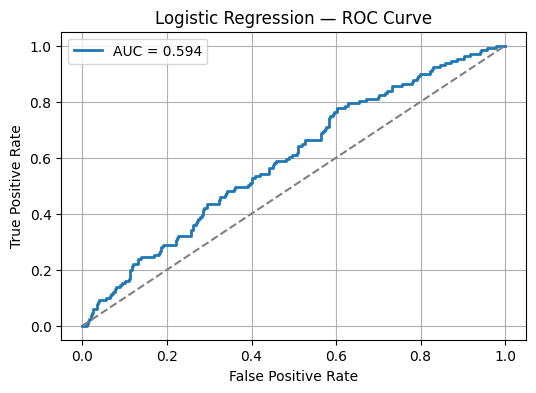


=== Evaluation: KNN ===


Outer CV (KNN): 100%|██████████| 5/5 [00:00<00:00,  6.14it/s]



>>> Best hyperparameters (last outer fold): {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Accuracy: 0.5973597359735974
ROC-AUC: 0.5691487274083087
Mean uncertainty: 0.4382918686163893
Uncertainty (Pred=0): 0.3235897727583135
Uncertainty (Pred=1): 0.6189557929707523
Confusion matrix:
 [[484 294]
 [ 72  59]]
              precision    recall  f1-score   support

           0       0.87      0.62      0.73       778
           1       0.17      0.45      0.24       131

    accuracy                           0.60       909
   macro avg       0.52      0.54      0.48       909
weighted avg       0.77      0.60      0.66       909



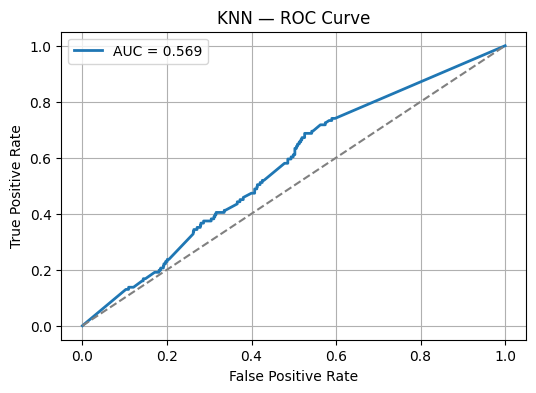


=== Evaluation: Random Forest ===


Outer CV (Random Forest): 100%|██████████| 5/5 [07:23<00:00, 88.67s/it]


>>> Best hyperparameters (last outer fold): {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': None}
Accuracy: 0.7073707370737073
ROC-AUC: 0.5549755685943601
Mean uncertainty: 0.7914385842358643
Uncertainty (Pred=0): 0.7446804666420785
Uncertainty (Pred=1): 0.9500095917278341
Confusion matrix:
 [[607 171]
 [ 95  36]]
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       778
           1       0.17      0.27      0.21       131

    accuracy                           0.71       909
   macro avg       0.52      0.53      0.52       909
weighted avg       0.77      0.71      0.73       909



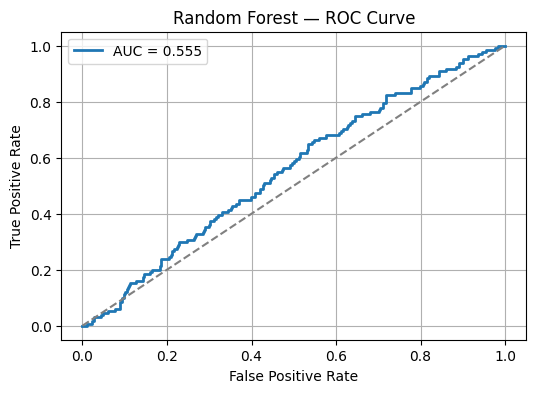


=== Evaluation: XGBoost ===


Outer CV (XGBoost): 100%|██████████| 5/5 [02:16<00:00, 27.22s/it]


>>> Best hyperparameters (last outer fold): {'clf__subsample': 0.9, 'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.9}
Accuracy: 0.7546754675467546
ROC-AUC: 0.5455758550991974
Mean uncertainty: 0.4563337211599848
Uncertainty (Pred=0): 0.39167392846752264
Uncertainty (Pred=1): 0.8115007253064375
Confusion matrix:
 [[662 116]
 [107  24]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       778
           1       0.17      0.18      0.18       131

    accuracy                           0.75       909
   macro avg       0.52      0.52      0.52       909
weighted avg       0.76      0.75      0.76       909



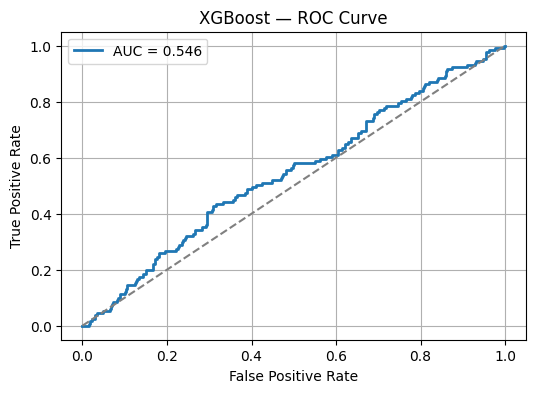


=== Evaluation: Gaussian Process ===


Outer CV (Gaussian Process):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise


>>> Best hyperparameters (last outer fold): {'clf__kernel': RBF(length_scale=1), 'clf__n_restarts_optimizer': 0}
Accuracy: 0.6853685368536854
ROC-AUC: 0.5611177613375459
Mean uncertainty: 0.945354531646473
Uncertainty (Pred=0): 0.9372121827660577
Uncertainty (Pred=1): 0.9676705989483516
Confusion matrix:
 [[579 199]
 [ 87  44]]
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       778
           1       0.18      0.34      0.24       131

    accuracy                           0.69       909
   macro avg       0.53      0.54      0.52       909
weighted avg       0.77      0.69      0.72       909



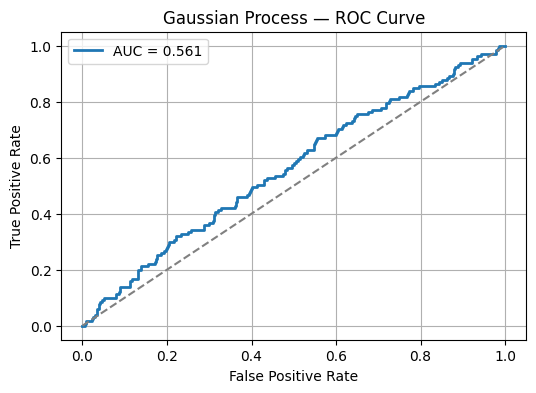


=== Summary Table ===


,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.588559,0.593987,0.876881,0.841819,0.926809
1,KNN,0.597360,0.569149,0.438292,0.323590,0.618956
2,Random Forest,0.707371,0.554976,0.791439,0.744680,0.950010
3,XGBoost,0.754675,0.545576,0.456334,0.391674,0.811501
4,Gaussian Process,0.685369,0.561118,0.945355,0.937212,0.967671


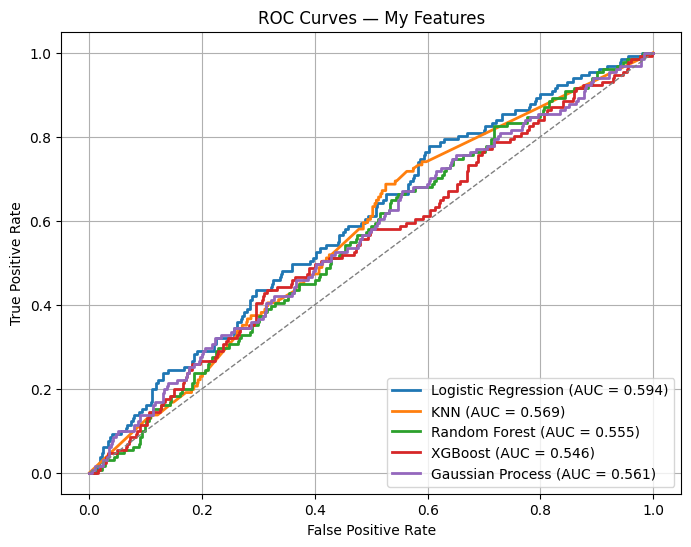

In [4]:

evaluate_models_cv_with_tuning(X, y, "My Features")